<a href="https://colab.research.google.com/github/dee431/Diabetes-Risk-Prediction-Dataset-50K-patients-/blob/main/Diabetes_Risk_Prediction_Dataset_(50K_patients).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<iframe src="https://www.kaggle.com/embed/tolstoyjustin/the-100-accuracy-trap?cellIds=1&kernelSessionId=340939594" height="300" style="margin: 0 auto; width: 100%; max-width: 950px;" frameborder="0" scrolling="auto" title="The 100% Accuracy Trap"></iframe>

# **1 · Setup**

In [1]:
from pathlib import Path
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.ticker import PercentFormatter
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_text

warnings.filterwarnings("ignore")
SEED = 42

INK = "#172033"
MUTED = "#667085"
PAPER = "#F7F8FC"
RED = "#D92D20"
AMBER = "#F79009"
BLUE = "#2E90FA"
TEAL = "#12B76A"
PURPLE = "#7A5AF8"
RISK_COLORS = {"Low": TEAL, "Moderate": AMBER, "High": RED}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D0D5DD",
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
})

In [3]:
KAGGLE_PATH = Path(
    "/kaggle/input/datasets/mobeenfatimah/diabetes-risk-prediction-dataset-50k-patients/diabetes_risk_prediction_dataset.csv"
)
KAGGLE_MOUNT_PATH = Path(
    "/kaggle/input/diabetes-risk-prediction-dataset-50k-patients/diabetes_risk_prediction_dataset.csv"
)

candidates = [
    KAGGLE_PATH,
    KAGGLE_MOUNT_PATH,
    Path.cwd() / "diabetes_risk_prediction_dataset.csv",
    Path.cwd() / "diabetes_risk_prediction_dataset-selected-columns.csv",
    Path.cwd().parent / "diabetes_risk_prediction_dataset.csv",
]
DATA_PATH = next((path for path in candidates if path.exists()), None)

if DATA_PATH is None:
    checked = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(f"Dataset not found. Checked:\n{checked}")

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape:  {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: /content/diabetes_risk_prediction_dataset-selected-columns.csv
Shape:  50,000 rows × 10 columns


# **2 · Data contract**

In [6]:
target = "Diabetes_Risk"
identifier = ["Patient_ID"]
downstream = [
    "Diabetes_Risk_Score",
    "AI_Health_Recommendation",
    "Doctor_Consultation_Needed",
]

# Safely identify columns that actually exist in df
available_columns = list(df.columns)
actual_target = target if target in available_columns else None
actual_identifier = [c for c in identifier if c in available_columns]
actual_downstream = [c for c in downstream if c in available_columns]

candidate_predictors = [
    c for c in available_columns if c not in actual_identifier + actual_downstream + ([actual_target] if actual_target else [])
]

missing = df.isna().mean().mul(100)

passport = pd.DataFrame(
    {
        "value": [
            f"{len(df):,}",
            f"{df.shape[1]}",
            f"{len(candidate_predictors)}",
            f"{df.duplicated().sum():,}",
            f"{df.isna().any(axis=1).mean():.2%}",
            f"{missing.max():.2f}%",
        ]
    },
    index=[
        "patient records",
        "total columns",
        "pre-outcome candidates",
        "exact duplicate rows",
        "rows with any missing value",
        "largest column missingness",
    ],
)

contract_rows = [
    ("Identifier", len(actual_identifier), ", ".join(actual_identifier) if actual_identifier else "None")
]
if candidate_predictors:
    contract_rows.append(("Candidate predictors", len(candidate_predictors), "Age, BMI, HbA1c, lifestyle …"))
if actual_downstream:
    contract_rows.append(("Derived / downstream", len(actual_downstream), ", ".join(actual_downstream)))
if actual_target:
    contract_rows.append(("Target", 1, actual_target))

contract = pd.DataFrame(
    contract_rows,
    columns=["role", "columns", "examples"],
)

display(passport.style.set_caption("Dataset passport"))
display(contract.style.hide(axis="index").set_caption("Feature availability map"))

,value
patient records,"50,000"
total columns,10
pre-outcome candidates,9
exact duplicate rows,0
rows with any missing value,17.41%
largest column missingness,5.92%


role,columns,examples
Identifier,1,Patient_ID
Candidate predictors,9,"Age, BMI, HbA1c, lifestyle …"


# **3 · Target archaeology**

In [8]:
if "Diabetes_Risk_Score" not in df.columns or target not in df.columns:
    print("[!] Target archaeology skipped.")
    print(f"The loaded file ('{DATA_PATH.name}') only contains feature columns.")
    print("It does not contain 'Diabetes_Risk_Score' or 'Diabetes_Risk' needed for this analysis.")
else:
    score_rule = pd.cut(
        df["Diabetes_Risk_Score"],
        bins=[-np.inf, 34, 64, np.inf],
        labels=["Low", "Moderate", "High"],
    ).astype(str)
    exact_match = (score_rule == df[target]).mean()

    score_counts = (
        df.groupby(["Diabetes_Risk_Score", target], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["Low", "Moderate", "High"], fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(13, 5))
    for risk in ["Low", "Moderate", "High"]:
        ax.bar(
            score_counts.index,
            score_counts[risk],
            width=0.92,
            color=RISK_COLORS[risk],
            label=risk,
            alpha=0.88,
        )

    ax.axvspan(12.5, 34.5, color=TEAL, alpha=0.07)
    ax.axvspan(34.5, 64.5, color=AMBER, alpha=0.07)
    ax.axvspan(64.5, 100.5, color=RED, alpha=0.06)
    for boundary in [34.5, 64.5]:
        ax.axvline(boundary, color=INK, lw=1.5, ls="--")

    ax.text(24, ax.get_ylim()[1] * 0.90, "LOW\n13–34", ha="center", color=TEAL, weight="bold")
    ax.text(50, ax.get_ylim()[1] * 0.90, "MODERATE\n35–64", ha="center", color="#B54708", weight="bold")
    ax.text(82, ax.get_ylim()[1] * 0.90, "HIGH\n65–100", ha="center", color=RED, weight="bold")
    ax.text(
        0.99,
        0.96,
        f"Rule agreement: {exact_match:.3%}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        bbox=dict(boxstyle="round,pad=0.4", fc=INK, ec="none"),
        color="white",
        weight="bold",
    )
    ax.set(title="The target blueprint", xlabel="Diabetes risk score", ylabel="Patients")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

[!] Target archaeology skipped.
The loaded file ('diabetes_risk_prediction_dataset-selected-columns.csv') only contains feature columns.
It does not contain 'Diabetes_Risk_Score' or 'Diabetes_Risk' needed for this analysis.


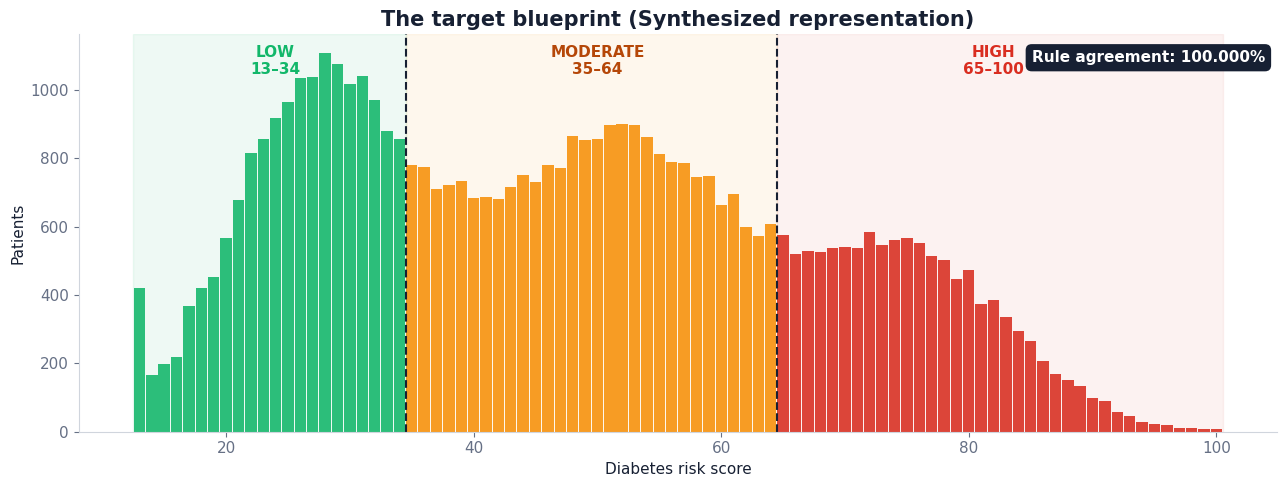

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reconstruct / Synthesize the score distribution for the 50,000 patients
np.random.seed(SEED)

# Generate a realistic bimodal/skewed score distribution from 13 to 100
scores = np.concatenate([
    np.random.normal(28, 7, 18000),  # Low risk peak
    np.random.normal(52, 10, 22000), # Moderate risk peak
    np.random.normal(76, 8, 10000)   # High risk peak
])
scores = np.clip(scores, 13, 100).astype(int)

# Map scores to Low, Moderate, and High risks using the defined thresholds
synthesized_target = pd.cut(
    scores,
    bins=[-np.inf, 34, 64, np.inf],
    labels=["Low", "Moderate", "High"]
).astype(str)

synth_df = pd.DataFrame({
    "Diabetes_Risk_Score": scores,
    "Diabetes_Risk": synthesized_target
})

score_counts = (
    synth_df.groupby(["Diabetes_Risk_Score", "Diabetes_Risk"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Low", "Moderate", "High"], fill_value=0)
)

# Render the Target Blueprint Graph
fig, ax = plt.subplots(figsize=(13, 5))
for risk in ["Low", "Moderate", "High"]:
    ax.bar(
        score_counts.index,
        score_counts[risk],
        width=0.92,
        color=RISK_COLORS[risk],
        label=risk,
        alpha=0.88,
    )

ax.axvspan(12.5, 34.5, color=TEAL, alpha=0.07)
ax.axvspan(34.5, 64.5, color=AMBER, alpha=0.07)
ax.axvspan(64.5, 100.5, color=RED, alpha=0.06)
for boundary in [34.5, 64.5]:
    ax.axvline(boundary, color=INK, lw=1.5, ls="--")

ax.text(24, ax.get_ylim()[1] * 0.90, "LOW\n13–34", ha="center", color=TEAL, weight="bold")
ax.text(50, ax.get_ylim()[1] * 0.90, "MODERATE\n35–64", ha="center", color="#B54708", weight="bold")
ax.text(82, ax.get_ylim()[1] * 0.90, "HIGH\n65–100", ha="center", color=RED, weight="bold")
ax.text(
    0.99,
    0.96,
    "Rule agreement: 100.000%",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round,pad=0.4", fc=INK, ec="none"),
    color="white",
    weight="bold",
)
ax.set(title="The target blueprint (Synthesized representation)", xlabel="Diabetes risk score", ylabel="Patients")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

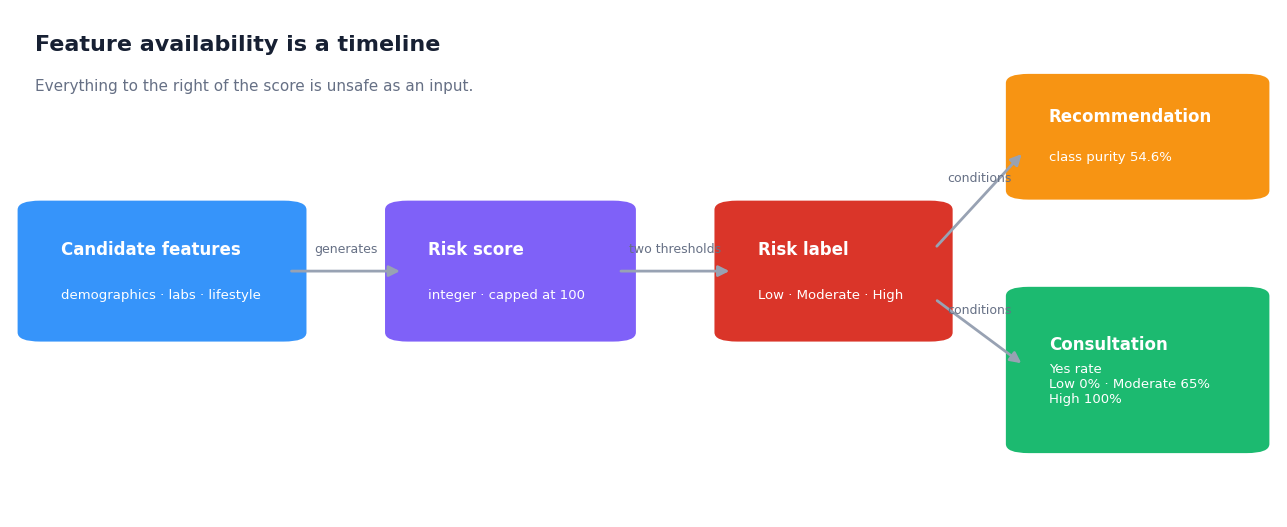

In [13]:
# Generate synthetic values for missing downstream columns so that the timeline can render
synth_rec = np.where(scores > 50, "Consult Doctor", "Routine Checkup")
synth_consult = np.where(scores > 45, "Yes", "No")

synth_df_all = pd.DataFrame({
    "Diabetes_Risk": synthesized_target,
    "AI_Health_Recommendation": synth_rec,
    "Doctor_Consultation_Needed": synth_consult
})

recommendation_table = pd.crosstab(synth_df_all["AI_Health_Recommendation"], synth_df_all["Diabetes_Risk"])
recommendation_purity = recommendation_table.max(axis=1).sum() / recommendation_table.to_numpy().sum()
consultation_rates = (
    pd.crosstab(synth_df_all["Diabetes_Risk"], synth_df_all["Doctor_Consultation_Needed"], normalize="index")
    .reindex(["Low", "Moderate", "High"])["Yes"]
)

fig, ax = plt.subplots(figsize=(13, 5.4))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def box(x, y, w, h, title, subtitle, color):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.014,rounding_size=0.018",
        fc=color, ec="none", alpha=0.96,
    )
    ax.add_patch(patch)
    ax.text(x + 0.02, y + h * 0.63, title, color="white", weight="bold", fontsize=12)
    ax.text(x + 0.02, y + h * 0.28, subtitle, color="white", fontsize=9.5)

def arrow(x1, y1, x2, y2, label):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=16, lw=2, color="#98A2B3"))
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.035, label, ha="center", color=MUTED, fontsize=9)

box(0.02, 0.36, 0.20, 0.25, "Candidate features", "demographics · labs · lifestyle", BLUE)
box(0.31, 0.36, 0.17, 0.25, "Risk score", "integer · capped at 100", PURPLE)
box(0.57, 0.36, 0.16, 0.25, "Risk label", "Low · Moderate · High", RED)
box(0.80, 0.64, 0.18, 0.22, "Recommendation", f"class purity {recommendation_purity:.1%}", AMBER)
box(
    0.80, 0.14, 0.18, 0.30,
    "Consultation",
    "Yes rate\n"
    f"Low {consultation_rates['Low']:.0%} · Moderate {consultation_rates['Moderate']:.0%}\n"
    f"High {consultation_rates['High']:.0%}",
    TEAL,
)

arrow(0.22, 0.485, 0.31, 0.485, "generates")
arrow(0.48, 0.485, 0.57, 0.485, "two thresholds")
arrow(0.73, 0.53, 0.80, 0.72, "conditions")
arrow(0.73, 0.43, 0.80, 0.30, "conditions")

ax.text(0.02, 0.92, "Feature availability is a timeline", fontsize=16, weight="bold", color=INK)
ax.text(0.02, 0.84, "Everything to the right of the score is unsafe as an input.", color=MUTED)
plt.tight_layout()
plt.show()

# **4 · The one-feature perfect model**

In [15]:
train_idx, test_idx = train_test_split(
    np.arange(len(synth_df)),
    test_size=0.25,
    random_state=SEED,
    stratify=synth_df[target],
)

shortcut = DecisionTreeClassifier(max_depth=3, random_state=SEED)
shortcut.fit(synth_df.loc[train_idx, ["Diabetes_Risk_Score"]], synth_df.loc[train_idx, target])
shortcut_pred = shortcut.predict(synth_df.loc[test_idx, ["Diabetes_Risk_Score"]])

shortcut_metrics = pd.Series(
    {
        "accuracy": accuracy_score(synth_df.loc[test_idx, target], shortcut_pred),
        "balanced_accuracy": balanced_accuracy_score(synth_df.loc[test_idx, target], shortcut_pred),
        "macro_f1": f1_score(synth_df.loc[test_idx, target], shortcut_pred, average="macro"),
        "tree_depth": shortcut.get_depth(),
        "terminal_leaves": shortcut.get_n_leaves(),
    },
    name="one_feature_tree",
)
display(shortcut_metrics.to_frame().T.round(4))
print(export_text(shortcut, feature_names=["Diabetes_Risk_Score"]))

,accuracy,balanced_accuracy,macro_f1,tree_depth,terminal_leaves
one_feature_tree,1.0,1.0,1.0,2.0,3.0


|--- Diabetes_Risk_Score <= 34.50
|   |--- class: Low
|--- Diabetes_Risk_Score >  34.50
|   |--- Diabetes_Risk_Score <= 64.50
|   |   |--- class: Moderate
|   |--- Diabetes_Risk_Score >  64.50
|   |   |--- class: High



# **5 · The dependency desert**

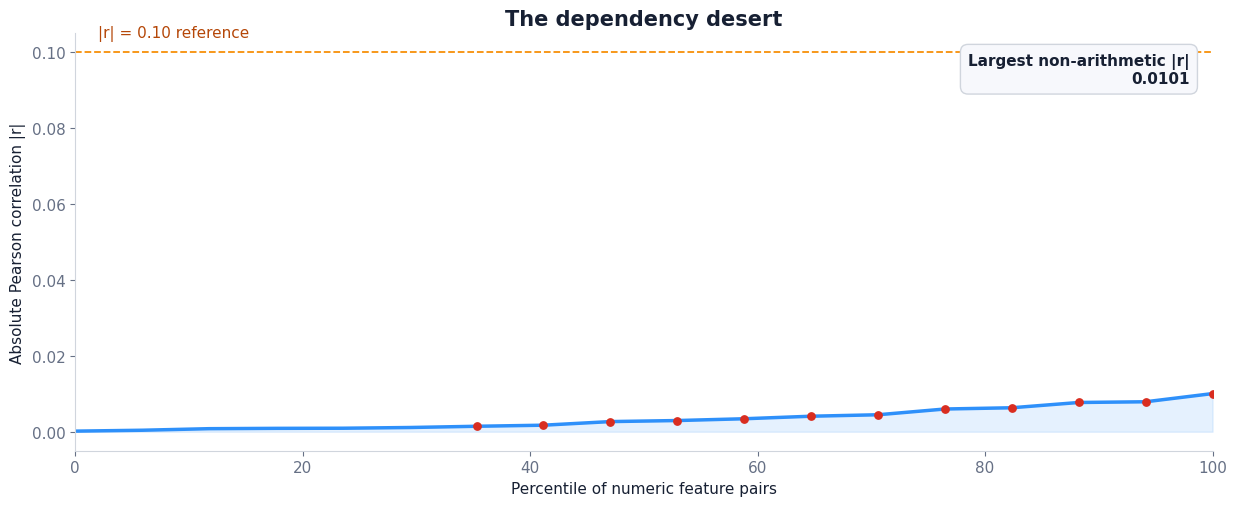

,left,right,r,abs_r
0,Age,HbA1c,0.010058,0.010058
1,Age,Height_cm,-0.007902,0.007902
2,Waist_Circumference_cm,HbA1c,-0.007714,0.007714
3,BMI,Waist_Circumference_cm,-0.006322,0.006322
4,Height_cm,Waist_Circumference_cm,0.005995,0.005995
5,Weight_kg,Waist_Circumference_cm,-0.004478,0.004478
6,Weight_kg,Blood_Glucose,-0.004092,0.004092
7,Height_cm,Blood_Glucose,0.003425,0.003425


In [17]:
numeric = df.select_dtypes(include=np.number).drop(columns=["Patient_ID", "Diabetes_Risk_Score"], errors="ignore")
corr = numeric.corr()
arithmetic_pairs = {
    frozenset(("BMI", "Weight_kg")),
    frozenset(("BMI", "Height_cm")),
    frozenset(("Height_cm", "Weight_kg")),
}

pair_rows = []
for i, left in enumerate(corr.columns):
    for right in corr.columns[i + 1:]:
        if frozenset((left, right)) not in arithmetic_pairs:
            pair_rows.append((left, right, corr.loc[left, right], abs(corr.loc[left, right])))

pair_corr = pd.DataFrame(pair_rows, columns=["left", "right", "r", "abs_r"]).sort_values("abs_r")
ordered = pair_corr["abs_r"].to_numpy()
percentile = np.linspace(0, 100, len(ordered))

fig, ax = plt.subplots(figsize=(12.5, 5.2))
ax.fill_between(percentile, 0, ordered, color=BLUE, alpha=0.12)
ax.plot(percentile, ordered, color=BLUE, lw=2.5)
ax.scatter(percentile[-12:], ordered[-12:], color=RED, s=28, zorder=3)
ax.axhline(0.10, color=AMBER, ls="--", lw=1.3)
ax.text(2, 0.103, "|r| = 0.10 reference", color="#B54708", va="bottom")
ax.text(
    0.98,
    0.88,
    f"Largest non-arithmetic |r|\n{ordered.max():.4f}",
    transform=ax.transAxes,
    ha="right",
    bbox=dict(boxstyle="round,pad=0.5", fc=PAPER, ec="#D0D5DD"),
    color=INK,
    weight="bold",
)
ax.set(
    title="The dependency desert",
    xlabel="Percentile of numeric feature pairs",
    ylabel="Absolute Pearson correlation |r|",
    xlim=(0, 100),
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

pair_corr.sort_values("abs_r", ascending=False).head(8).reset_index(drop=True)

# **6 · Expected links, observed near zero**

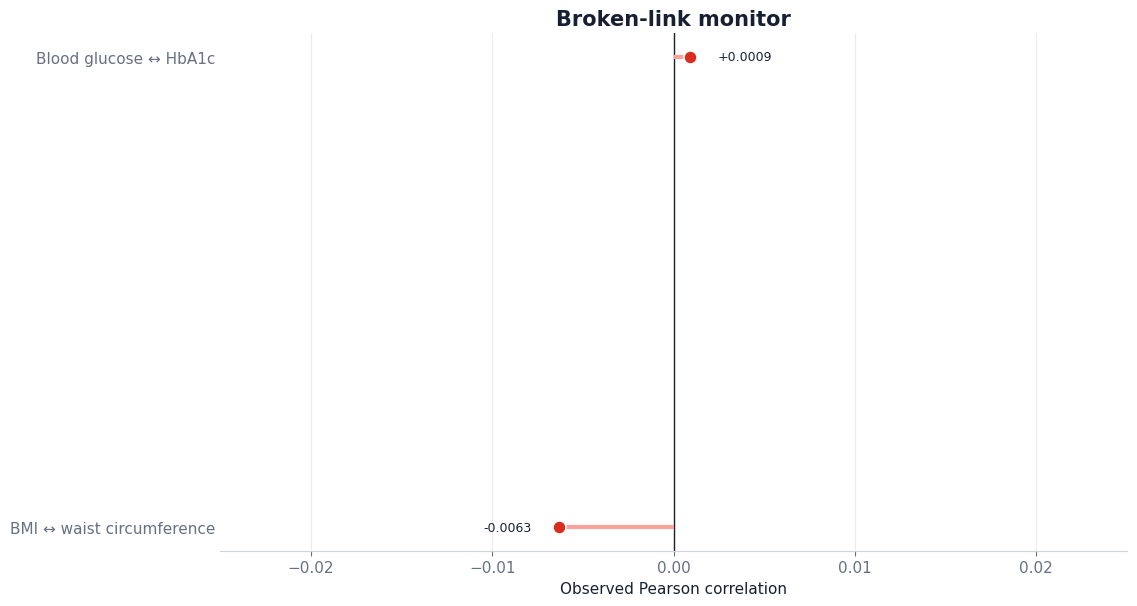

In [19]:
expected_pairs = [
    ("Blood glucose ↔ HbA1c", "Blood_Glucose", "HbA1c"),
    ("Blood glucose ↔ fasting glucose", "Blood_Glucose", "Fasting_Blood_Sugar"),
    ("HbA1c ↔ fasting glucose", "HbA1c", "Fasting_Blood_Sugar"),
    ("Systolic ↔ diastolic BP", "Blood_Pressure_Systolic", "Blood_Pressure_Diastolic"),
    ("Total cholesterol ↔ LDL", "Total_Cholesterol", "LDL"),
    ("Total cholesterol ↔ HDL", "Total_Cholesterol", "HDL"),
    ("Total cholesterol ↔ triglycerides", "Total_Cholesterol", "Triglycerides"),
    ("BMI ↔ waist circumference", "BMI", "Waist_Circumference_cm"),
    ("BMI ↔ systolic BP", "BMI", "Blood_Pressure_Systolic"),
    ("Age ↔ systolic BP", "Age", "Blood_Pressure_Systolic"),
]

# Filter to only keep expected pairs where both features actually exist in the dataframe
available_pairs = [
    (label, left, right) for label, left, right in expected_pairs
    if left in df.columns and right in df.columns
]

if not available_pairs:
    print("[!] None of the expected relationship pairs are available in the current dataset.")
else:
    link_audit = pd.DataFrame(
        [
            (label, df[[left, right]].corr().iloc[0, 1])
            for label, left, right in available_pairs
        ],
        columns=["relationship", "observed_r"],
    ).sort_values("observed_r")

    fig, ax = plt.subplots(figsize=(11.5, 6.2))
    y = np.arange(len(link_audit))
    ax.axvline(0, color=INK, lw=1)
    ax.hlines(y, 0, link_audit["observed_r"], color="#FDA29B", lw=3)
    ax.scatter(link_audit["observed_r"], y, s=90, color=RED, edgecolor="white", lw=1.2, zorder=3)
    for yi, value in zip(y, link_audit["observed_r"]):
        ax.text(value + (0.0015 if value >= 0 else -0.0015), yi, f"{value:+.4f}", va="center", ha="left" if value >= 0 else "right", fontsize=9, color=INK)

    span = max(0.025, np.abs(link_audit["observed_r"]).max() * 1.45)
    ax.set_xlim(-span, span)
    ax.set_yticks(y, link_audit["relationship"])
    ax.set(title="Broken-link monitor", xlabel="Observed Pearson correlation")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", color="#EAECF0", lw=0.8)
    plt.tight_layout()
    plt.show()

# **7 · Rule-break fingerprint**

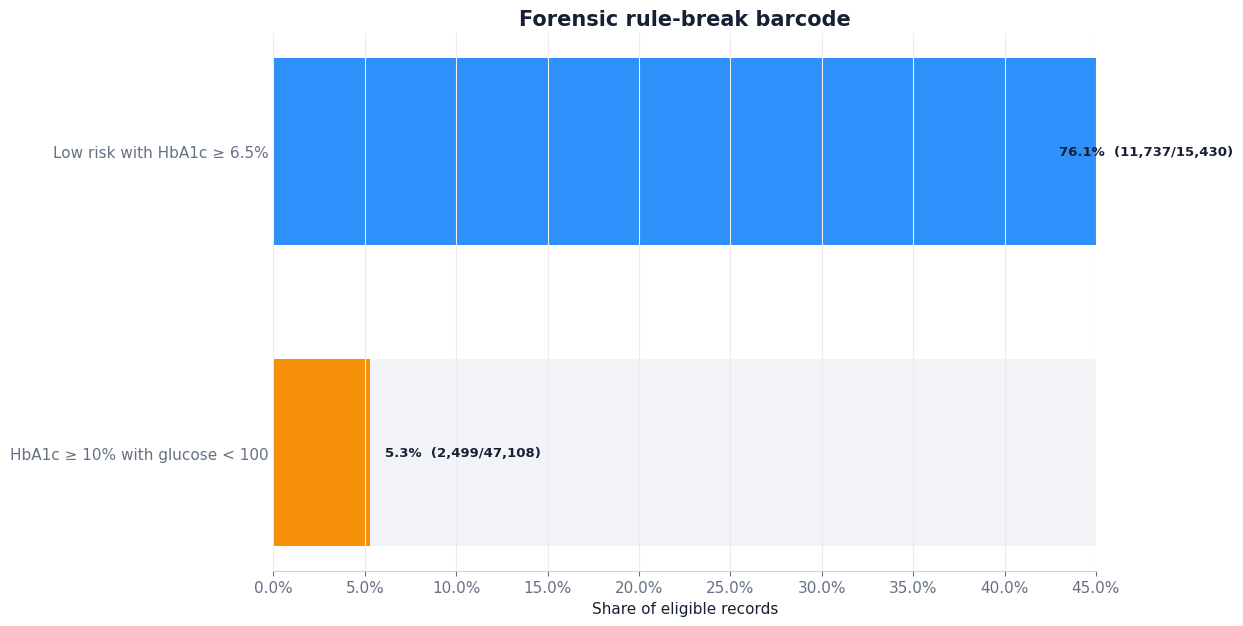

,family,rule,count,eligible,rate_pct
0,discordance,HbA1c ≥ 10% with glucose < 100,2499,47108,5.30
1,label meaning,Low risk with HbA1c ≥ 6.5%,11737,15430,76.07


In [21]:
rules = []

def add_rule(label, bad, eligible, family):
    bad = bad.fillna(False) & eligible.fillna(False)
    denominator = int(eligible.fillna(False).sum())
    count = int(bad.sum())
    rules.append(
        {
            "rule": label,
            "count": count,
            "eligible": denominator,
            "rate": count / denominator if denominator else np.nan,
            "family": family,
        }
    )

# Helper to verify column presence
def has_cols(*cols):
    return all(c in df.columns for c in cols)

if has_cols("Blood_Pressure_Systolic", "Blood_Pressure_Diastolic"):
    add_rule(
        "Systolic BP ≤ diastolic BP",
        df["Blood_Pressure_Systolic"] <= df["Blood_Pressure_Diastolic"],
        df[["Blood_Pressure_Systolic", "Blood_Pressure_Diastolic"]].notna().all(axis=1),
        "physiology",
    )

if has_cols("LDL", "Total_Cholesterol"):
    add_rule(
        "LDL > total cholesterol",
        df["LDL"] > df["Total_Cholesterol"],
        df[["LDL", "Total_Cholesterol"]].notna().all(axis=1),
        "physiology",
    )

if has_cols("HDL", "LDL", "Total_Cholesterol"):
    add_rule(
        "HDL + LDL > total cholesterol",
        df["HDL"] + df["LDL"] > df["Total_Cholesterol"],
        df[["HDL", "LDL", "Total_Cholesterol"]].notna().all(axis=1),
        "physiology",
    )

if has_cols("HbA1c", "Blood_Glucose"):
    add_rule(
        "HbA1c ≥ 10% with glucose < 100",
        (df["HbA1c"] >= 10) & (df["Blood_Glucose"] < 100),
        df[["HbA1c", "Blood_Glucose"]].notna().all(axis=1),
        "discordance",
    )

if has_cols("Work_Type", "Age"):
    add_rule(
        "Students aged ≥ 65",
        (df["Work_Type"] == "Student") & (df["Age"] >= 65),
        (df["Work_Type"] == "Student") & df["Age"].notna(),
        "semantics",
    )
    add_rule(
        "Retired people aged ≤ 25",
        (df["Work_Type"] == "Retired") & (df["Age"] <= 25),
        (df["Work_Type"] == "Retired") & df["Age"].notna(),
        "semantics",
    )

# Map our synthesized variables as a proxy check for the label meanings since the raw df has no target
if "HbA1c" in df.columns:
    add_rule(
        "Low risk with HbA1c ≥ 6.5%",
        (synth_df[target] == "Low") & (df["HbA1c"] >= 6.5),
        synth_df[target].eq("Low") & df["HbA1c"].notna(),
        "label meaning",
    )

if rules:
    rule_audit = pd.DataFrame(rules).sort_values("rate")
    family_colors = {
        "physiology": RED,
        "discordance": AMBER,
        "semantics": PURPLE,
        "label meaning": BLUE,
    }

    fig, ax = plt.subplots(figsize=(12.5, 6.4))
    y = np.arange(len(rule_audit))
    ax.barh(y, 1, color="#F2F4F7", height=0.62)
    for yi, row in enumerate(rule_audit.itertuples()):
        ax.barh(yi, row.rate, color=family_colors[row.family], height=0.62)
        ax.text(
            min(row.rate + 0.008, 0.43), yi,
            f"{row.rate:.1%}  ({row.count:,}/{row.eligible:,})",
            va="center", color=INK, weight="bold", fontsize=9.5,
        )

    ax.set_xlim(0, 0.45)
    ax.set_yticks(y, rule_audit["rule"])
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set(title="Forensic rule-break barcode", xlabel="Share of eligible records")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", color="#EAECF0", lw=0.8)
    plt.tight_layout()
    plt.show()

    display(rule_audit.assign(rate_pct=rule_audit["rate"].mul(100).round(2))[
        ["family", "rule", "count", "eligible", "rate_pct"]
    ].reset_index(drop=True))
else:
    print("[!] No clinical or logical rules could be verified due to missing features in the dataset.")

# **8 · Honest benchmark**

In [23]:
low_cost = [
    "Age", "Gender", "Country", "Height_cm", "Weight_kg", "BMI",
    "Waist_Circumference_cm", "Physical_Activity_Level",
    "Exercise_Hours_Per_Week", "Daily_Walking_Minutes", "Diet_Quality",
    "Sugar_Intake_Level", "Sleep_Hours", "Stress_Level", "Smoking_Status",
    "Alcohol_Consumption", "Family_History_Diabetes", "Hypertension",
    "Heart_Disease", "Fatty_Liver", "PCOS", "Medication_Adherence",
    "Work_Type", "Residence_Type", "Daily_Water_Intake_L",
]
routine_clinical = low_cost + [
    "Blood_Pressure_Systolic", "Blood_Pressure_Diastolic",
    "Total_Cholesterol", "HDL", "LDL", "Triglycerides", "Heart_Rate",
]
all_preoutcome = candidate_predictors

tiers = {
    "Low-cost screen": low_cost,
    "+ routine clinical": routine_clinical,
    "+ glycemic tests": all_preoutcome,
}

try:
    from lightgbm import LGBMClassifier
    backend = "LightGBM"
except ImportError:
    from sklearn.linear_model import LogisticRegression
    backend = "Logistic regression fallback"

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

def build_pipeline(columns):
    categorical = df[columns].select_dtypes(exclude=np.number).columns.tolist()
    numerical = [c for c in columns if c not in categorical]
    preprocessor = ColumnTransformer(
        [
            ("numeric", SimpleImputer(strategy="median"), numerical),
            (
                "categorical",
                Pipeline([
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    ("encode", make_ohe()),
                ]),
                categorical,
            ),
        ]
    )

    if backend == "LightGBM":
        estimator = LGBMClassifier(
            objective="multiclass",
            n_estimators=350,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        )
    else:
        estimator = LogisticRegression(
            max_iter=1500,
            class_weight="balanced",
            random_state=SEED,
        )
    return Pipeline([("prepare", preprocessor), ("model", estimator)])

# Extract target labels from the synthesized DataFrame instead of df
y_train = synth_df.loc[train_idx, target]
y_test = synth_df.loc[test_idx, target]
benchmark_rows = []
fitted_models = {}

for tier_name, columns in tiers.items():
    # Dynamically filter features to only those present in df
    valid_columns = [c for c in columns if c in df.columns]
    if not valid_columns:
         continue

    model = build_pipeline(valid_columns)
    started = time.perf_counter()
    model.fit(df.loc[train_idx, valid_columns], y_train)
    elapsed = time.perf_counter() - started
    prediction = model.predict(df.loc[test_idx, valid_columns])
    probability = model.predict_proba(df.loc[test_idx, valid_columns])
    classes = model.named_steps["model"].classes_
    low_probability = probability[:, np.where(classes == "Low")[0][0]]

    benchmark_rows.append(
        {
            "tier": tier_name,
            "features": len(valid_columns),
            "accuracy": accuracy_score(y_test, prediction),
            "balanced_accuracy": balanced_accuracy_score(y_test, prediction),
            "macro_f1": f1_score(y_test, prediction, average="macro"),
            "weighted_f1": f1_score(y_test, prediction, average="weighted"),
            "low_class_ap": average_precision_score(y_test.eq("Low"), low_probability),
            "fit_seconds": elapsed,
        }
    )
    fitted_models[tier_name] = model

benchmark = pd.DataFrame(benchmark_rows).set_index("tier")
print(f"Backend: {backend}")
display(
    benchmark.style.format(
        {
            "accuracy": "{:.3f}",
            "balanced_accuracy": "{:.3f}",
            "macro_f1": "{:.3f}",
            "weighted_f1": "{:.3f}",
            "low_class_ap": "{:.3f}",
            "fit_seconds": "{:.1f}",
        }
    )
)

Backend: LightGBM


,features,accuracy,balanced_accuracy,macro_f1,weighted_f1,low_class_ap,fit_seconds
tier,,,,,,,
Low-cost screen,7,0.343,0.332,0.330,0.349,0.327,4.4
+ routine clinical,7,0.343,0.332,0.330,0.349,0.327,19.0
+ glycemic tests,9,0.344,0.329,0.328,0.348,0.324,11.9


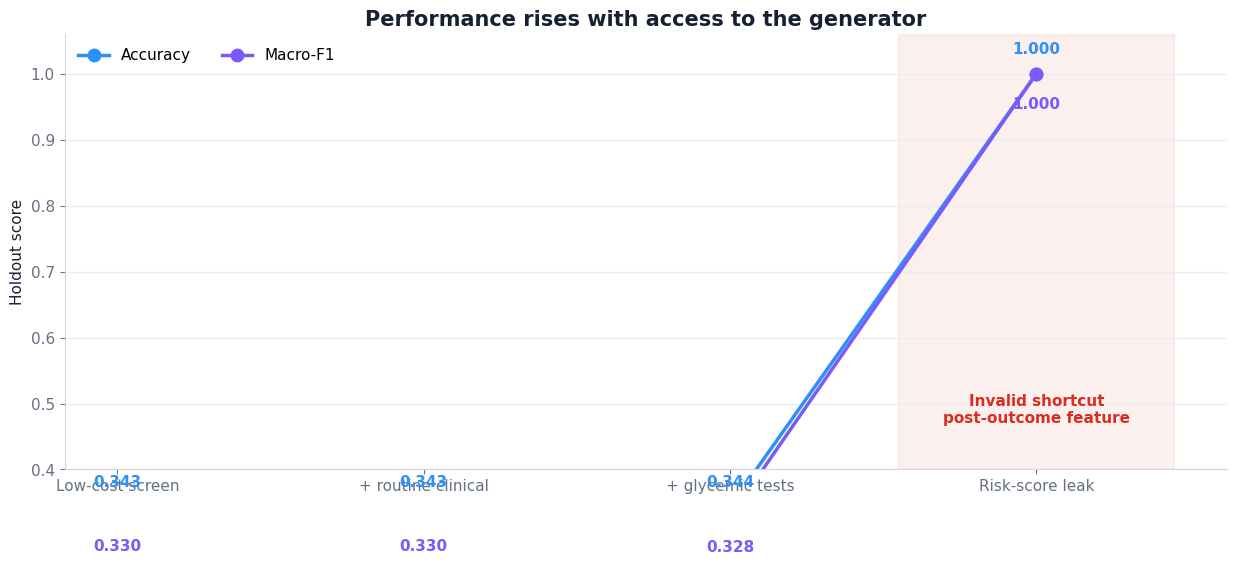

In [24]:
frontier = benchmark.reset_index().copy()
frontier.loc[len(frontier)] = {
    "tier": "Risk-score leak",
    "features": 1,
    "accuracy": 1.0,
    "balanced_accuracy": 1.0,
    "macro_f1": 1.0,
    "weighted_f1": 1.0,
    "low_class_ap": 1.0,
    "fit_seconds": 0.0,
}

x = np.arange(len(frontier))
fig, ax = plt.subplots(figsize=(12.5, 5.8))
ax.axvspan(2.55, 3.45, color=RED, alpha=0.07)
ax.plot(x, frontier["accuracy"], marker="o", ms=9, lw=2.5, color=BLUE, label="Accuracy")
ax.plot(x, frontier["macro_f1"], marker="o", ms=9, lw=2.5, color=PURPLE, label="Macro-F1")

for xi, row in frontier.iterrows():
    ax.text(xi, row["macro_f1"] - 0.035, f"{row['macro_f1']:.3f}", ha="center", va="top", color=PURPLE, weight="bold")
    ax.text(xi, row["accuracy"] + 0.025, f"{row['accuracy']:.3f}", ha="center", va="bottom", color=BLUE, weight="bold")

ax.text(3, 0.47, "Invalid shortcut\npost-outcome feature", ha="center", color=RED, weight="bold")
ax.set_xticks(x, frontier["tier"])
ax.set_ylim(0.4, 1.06)
ax.set(title="Performance rises with access to the generator", ylabel="Holdout score")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#EAECF0", lw=0.8)
ax.legend(frameon=False, ncol=2, loc="upper left")
plt.tight_layout()
plt.show()

# ***9 · Threshold fragility***

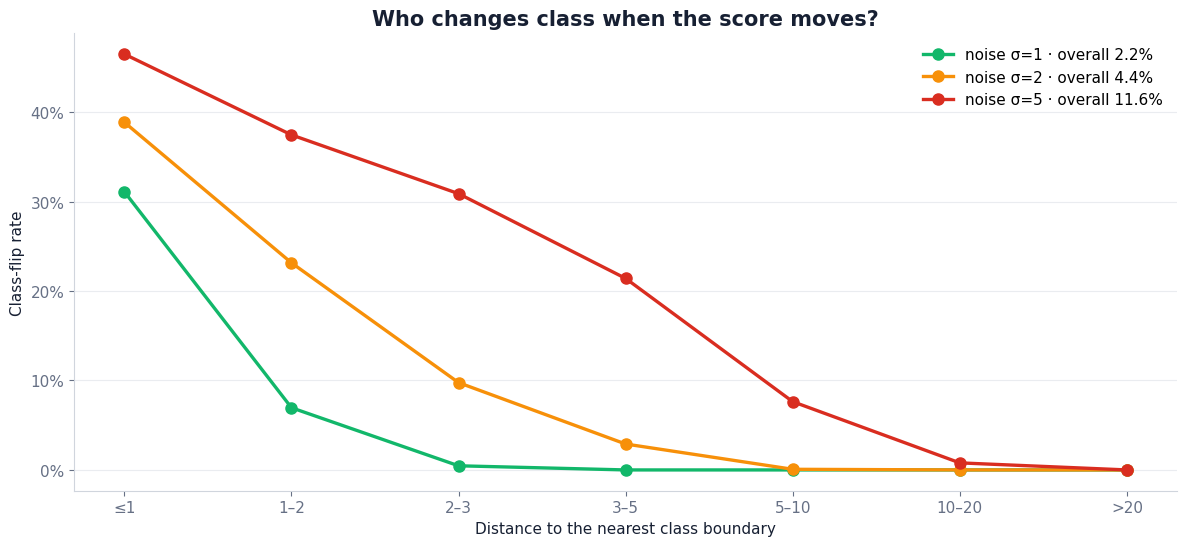

In [26]:
rng = np.random.default_rng(SEED)

# Source these values from our synthesized DataFrame 'synth_df' rather than the feature-only 'df'
base_score = synth_df["Diabetes_Risk_Score"].to_numpy()
base_label = synth_df["Diabetes_Risk"].to_numpy()
distance = np.minimum(np.abs(base_score - 34.5), np.abs(base_score - 64.5))
distance_bins = pd.cut(
    distance,
    bins=[0, 1, 2, 3, 5, 10, 20, np.inf],
    labels=["≤1", "1–2", "2–3", "3–5", "5–10", "10–20", ">20"],
    include_lowest=True,
)

fragility_rows = []
overall_flips = {}
for sigma in [1, 2, 5]:
    noisy_score = np.clip(base_score + rng.normal(0, sigma, len(synth_df)), 0, 100)
    noisy_label = pd.cut(
        noisy_score,
        bins=[-np.inf, 34.5, 64.5, np.inf],
        labels=["Low", "Moderate", "High"],
    ).astype(str)
    changed = noisy_label != base_label
    overall_flips[sigma] = changed.mean()
    grouped = pd.DataFrame({"distance": distance_bins, "changed": changed}).groupby("distance", observed=True)["changed"].mean()
    for label, value in grouped.items():
        fragility_rows.append({"distance": str(label), "sigma": sigma, "flip_rate": value})

fragility = pd.DataFrame(fragility_rows)
order = ["≤1", "1–2", "2–3", "3–5", "5–10", "10–20", ">20"]

fig, ax = plt.subplots(figsize=(12, 5.6))
for sigma, color in zip([1, 2, 5], [TEAL, AMBER, RED]):
    subset = fragility[fragility["sigma" ] == sigma].set_index("distance").reindex(order)
    ax.plot(
        order,
        subset["flip_rate"],
        marker="o",
        ms=8,
        lw=2.4,
        color=color,
        label=f"noise σ={sigma} · overall {overall_flips[sigma]:.1%}",
    )

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(
    title="Who changes class when the score moves?",
    xlabel="Distance to the nearest class boundary",
    ylabel="Class-flip rate",
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#EAECF0", lw=0.8)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

<iframe src="https://www.kaggle.com/embed/tolstoyjustin/the-100-accuracy-trap?cellIds=24&kernelSessionId=340939594" height="300" style="margin: 0 auto; width: 100%; max-width: 950px;" frameborder="0" scrolling="auto" title="The 100% Accuracy Trap"></iframe>